# Libraries

In [ ]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Input, Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D, Activation
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

TensorFlow version: 2.20.0


In [ ]:
# GPU Check
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available:", len(gpus))
if gpus:
    for gpu in gpus:
        print("  ->", gpu)
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU (Colab).")


Num GPUs Available: 1
  -> PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


#Project Configuration

In [ ]:
# Configuration
IMAGE_SIZE   = 224
RESIZE_SIZE  = 256
BATCH_SIZE   = 64
SEED         = 42
NUM_CLASSES  = 10
AUTOTUNE     = tf.data.AUTOTUNE

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Configuration Loaded Successfully")
print(f"Image Size   : {IMAGE_SIZE}")
print(f"Batch Size   : {BATCH_SIZE}")
print(f"Num Classes  : {NUM_CLASSES}")


Configuration Loaded Successfully
Image Size   : 224
Batch Size   : 64
Num Classes  : 10


# Load Dataset


In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()

y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

print("Full train set :", X_train_full.shape, y_train_full.shape)
print("Test set       :", X_test.shape, y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2958s 17us/step
Full train set : (50000, 32, 32, 3) (50000,)
Test set       : (10000, 32, 32, 3) (10000,)


In [ ]:
# Train / Validation split (stratified, 90/10)
X_train, x_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size = 0.10,
    random_state = SEED,
    stratify = y_train_full
)

print("Train set      :", X_train.shape, y_train.shape)
print("Validation set :", x_val.shape, y_val.shape)
print("Test set       :", X_test.shape, y_test.shape)

Train set      : (45000, 32, 32, 3) (45000,)
Validation set : (5000, 32, 32, 3) (5000,)
Test set       : (10000, 32, 32, 3) (10000,)


# EDA

Images per class (training set)
airplane    : 4500
automobile  : 4500
bird        : 4500
cat         : 4500
deer        : 4500
dog         : 4500
frog        : 4500
horse       : 4500
ship        : 4500
truck       : 4500


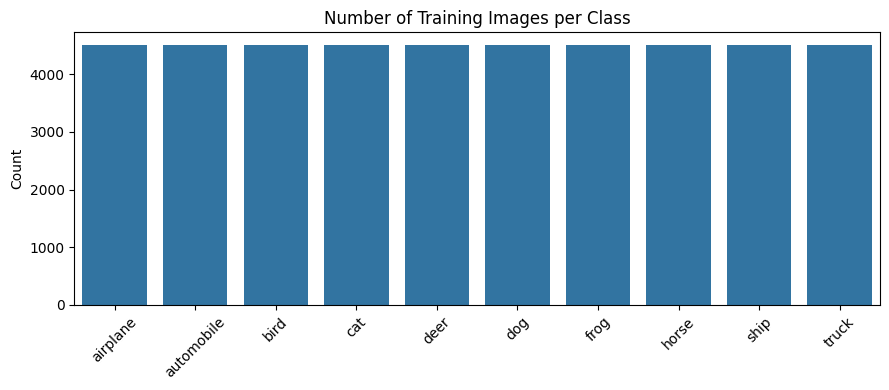

In [ ]:
# Class distribution in the training set
print("=" * 60)
print("Images per class (training set)")
print("=" * 60)
unique, counts = np.unique(y_train, return_counts=True)
for cls_idx, cnt in zip(unique, counts):
    print(f"{CLASS_NAMES[cls_idx]:12s}: {cnt}")

plt.figure(figsize=(9, 4))
sns.barplot(x=[CLASS_NAMES[i] for i in unique], y=counts)
plt.title("Number of Training Images per Class")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.tight_layout()
plt.show()


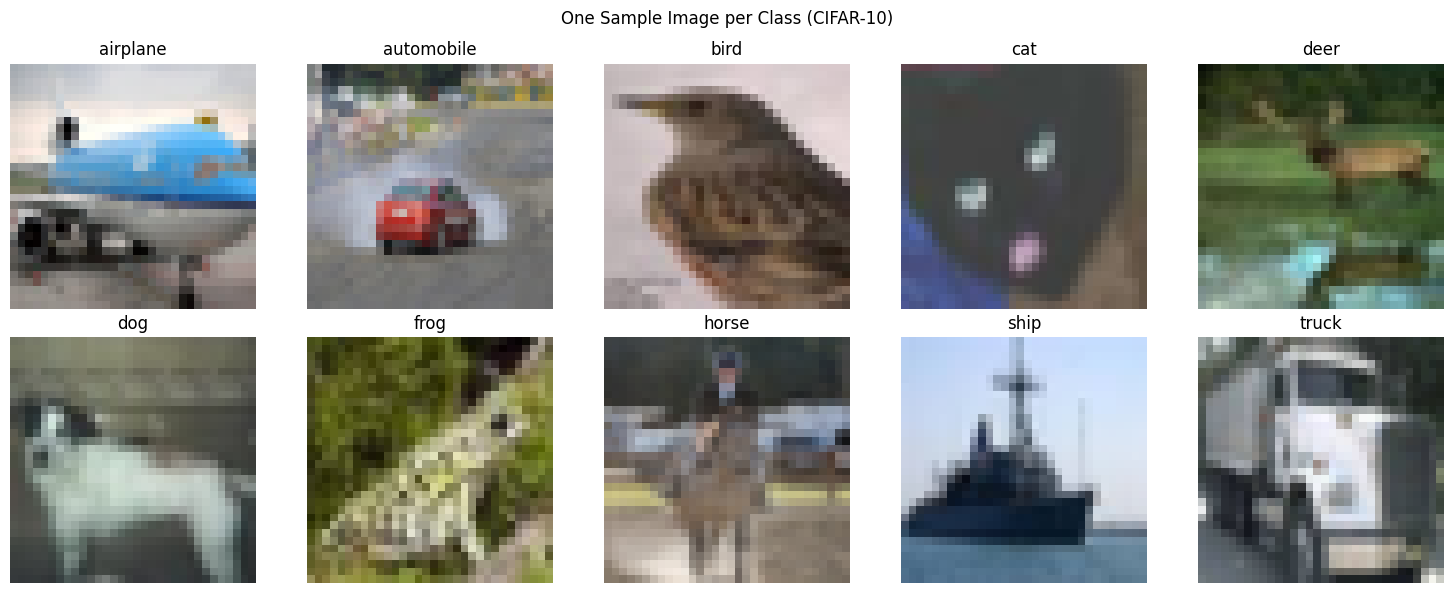

In [ ]:
# One random sample image per class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for cls_idx in range(NUM_CLASSES):
    idx = np.where(y_train == cls_idx)[0]
    sample_idx = np.random.choice(idx)
    axes[cls_idx].imshow(X_train[sample_idx])
    axes[cls_idx].set_title(CLASS_NAMES[cls_idx])
    axes[cls_idx].axis("off")
plt.suptitle("One Sample Image per Class (CIFAR-10)")
plt.tight_layout()
plt.show()


In [ ]:
# Sanity checks: missing / corrupt data
print("Any NaN pixel values (train):", np.isnan(X_train.astype(np.float32)).any())
print("Pixel value range (train)   :", X_train.min(), "-", X_train.max())
print("Any missing labels (train)  :", pd.isnull(y_train).any())


Any NaN pixel values (train): False
Pixel value range (train)   : 0 - 255
Any missing labels (train)  : False


# Data Preprocessing

In [ ]:
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)

def normalize_imagenet(image):
    """Scale to [0,1] then normalize using ImageNet mean & std."""
    image = tf.cast(image, tf.float32) / 255.0
    image = (image - IMAGENET_MEAN) / IMAGENET_STD
    return image

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.Resizing(RESIZE_SIZE, RESIZE_SIZE),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.06),
    layers.RandomCrop(IMAGE_SIZE, IMAGE_SIZE),
], name="data_augmentation")

resize_only = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
], name="resize_only")

def make_train_fn():
    def _fn(image, label):
        image = data_augmentation(image, training=True)
        image = normalize_imagenet(image)
        return image, label
    return _fn

def make_eval_fn():
    def _fn(image, label):
        image = resize_only(image, training=False)
        image = normalize_imagenet(image)
        return image, label
    return _fn


In [ ]:
def build_dataset(images, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if training:
        ds = ds.shuffle(buffer_size=5000, seed=SEED)
        ds = ds.map(make_train_fn(), num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(make_eval_fn(), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_dataset = build_dataset(X_train, y_train, training=True)
val_dataset   = build_dataset(x_val,   y_val,   training=False)
test_dataset  = build_dataset(X_test,  y_test,  training=False)

print("Train batches :", tf.data.experimental.cardinality(train_dataset).numpy())
print("Val batches   :", tf.data.experimental.cardinality(val_dataset).numpy())
print("Test batches  :", tf.data.experimental.cardinality(test_dataset).numpy())


Train batches : 704
Val batches   : 79
Test batches  : 157


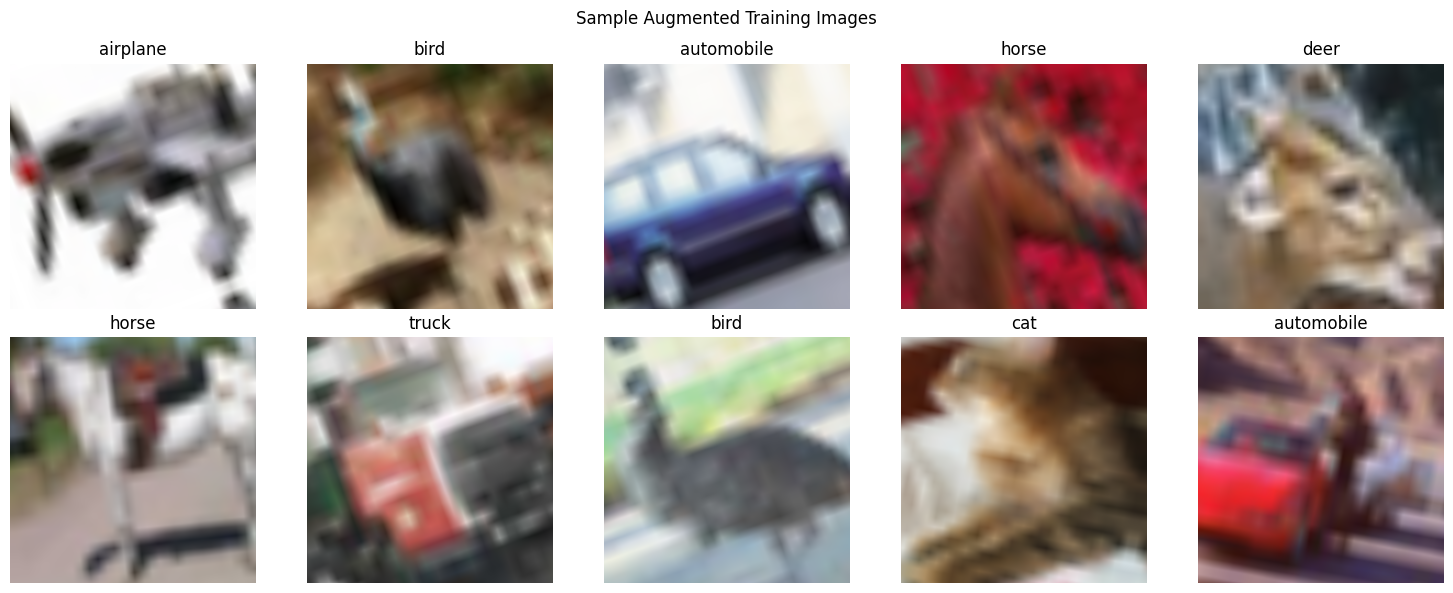

In [ ]:
sample_images, sample_labels = next(iter(train_dataset))

def denormalize(img):
    img = img * IMAGENET_STD + IMAGENET_MEAN
    return tf.clip_by_value(img, 0, 1)

plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(denormalize(sample_images[i]))
    plt.title(CLASS_NAMES[sample_labels[i].numpy()])
    plt.axis("off")
plt.suptitle("Sample Augmented Training Images")
plt.tight_layout()
plt.show()


# 6. Model Architecture - ResNet50


In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)

# Freeze the backbone for the feature-extraction phase
base_model.trainable = False

print("Number of layers in ResNet50 backbone:", len(base_model.layers))


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Number of layers in ResNet50 backbone: 175


In [ ]:
L2_WEIGHT_DECAY = 1e-4

inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)

x = Dense(
    512,
    kernel_initializer="he_normal",
    kernel_regularizer=l2(L2_WEIGHT_DECAY)
)(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = Dropout(0.5)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax",
    kernel_initializer="glorot_uniform",
    kernel_regularizer=l2(L2_WEIGHT_DECAY)
)(x)

model = Model(inputs, outputs, name="resnet50_cifar10_transfer")
model.summary()


Model: "resnet50_cifar10_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,643,978 (94.01 MB)

 Trainable params: 1,055,242 (4.03 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

In [ ]:
# Model compile
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
# Callbacks
early_stop_fe = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_fe = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint_fe = ModelCheckpoint(
    "best_feature_extraction_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)


In [ ]:
EPOCHS_FEATURE_EXTRACTION = 5

history_fe = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_FEATURE_EXTRACTION,
    callbacks=[early_stop_fe, reduce_lr_fe, checkpoint_fe]
)


Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.4299 - loss: 1.6657
Epoch 1: val_accuracy improved from None to 0.46560, saving model to best_feature_extraction_model.keras

Epoch 1: finished saving model to best_feature_extraction_model.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 508s 721ms/step - accuracy: 0.4439 - loss: 1.6280 - val_accuracy: 0.4656 - val_loss: 1.5611 - learning_rate: 0.0010
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - accuracy: 0.4716 - loss: 1.5467
Epoch 2: val_accuracy did not improve from 0.46560
704/704 ━━━━━━━━━━━━━━━━━━━━ 540s 691ms/step - accuracy: 0.4781 - loss: 1.5355 - val_accuracy: 0.4082 - val_loss: 1.8276 - learning_rate: 0.0010
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - accuracy: 0.4847 - loss: 1.5136
Epoch 3: val_accuracy did not improve from 0.46560
704/704 ━━━━━━━━━━━━━━━━━━━━ 508s 699ms/step - accuracy: 0.4899 - loss: 1.5039 - val_accuracy: 0.4392 - val_loss: 1.7514 - learning_rate: 0.0010
Epoch 4/5
704/704 ━━━━━━━━

In [ ]:
# Feature-extraction phase: test set evaluation
fe_test_loss, fe_test_acc = model.evaluate(test_dataset)
print(f"[Feature Extraction] Test Loss: {fe_test_loss:.4f} | Test Accuracy: {fe_test_acc:.4f}")


In [ ]:
def plot_history(history, title_suffix=""):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Accuracy {title_suffix}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"Loss {title_suffix}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_fe, title_suffix="(Feature Extraction)")


# 8. Fine-Tuning


In [ ]:
N_UNFREEZE = 30  # number of trailing backbone layers to unfreeze - experiment with this

base_model.trainable = True

# Freeze everything except the last N_UNFREEZE layers
for layer in base_model.layers[:-N_UNFREEZE]:
    layer.trainable = False

# Keep BatchNorm layers frozen even within the unfrozen block (standard practice)
for layer in base_model.layers[-N_UNFREEZE:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Unfrozen backbone layers: {trainable_count} / {len(base_model.layers)}")


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-5, weight_decay=1e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
early_stop_ft = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_ft = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-8,
    verbose=1
)

checkpoint_ft = ModelCheckpoint(
    "best_fine_tuned_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)


In [ ]:
EPOCHS_FINE_TUNE = 15

history_ft = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS_FINE_TUNE,
    callbacks=[early_stop_ft, reduce_lr_ft, checkpoint_ft]
)


In [ ]:
ft_test_loss, ft_test_acc = model.evaluate(test_dataset)
print(f"[Fine-Tuned] Test Loss: {ft_test_loss:.4f} | Test Accuracy: {ft_test_acc:.4f}")


In [ ]:
plot_history(history_ft, title_suffix="(Fine-Tuning)")


In [ ]:
# Comparison
comparison_df = pd.DataFrame({
    "Phase": ["Feature Extraction", "Fine-Tuning"],
    "Test Loss": [fe_test_loss, ft_test_loss],
    "Test Accuracy": [fe_test_acc, ft_test_acc],
    "Best Val Accuracy": [max(history_fe.history["val_accuracy"]),
                           max(history_ft.history["val_accuracy"])],
    "Best Val Loss": [min(history_fe.history["val_loss"]),
                       min(history_ft.history["val_loss"])],
})
comparison_df


# 9. Evaluation

In [ ]:
# Predictions on the test set
y_pred_probs = model.predict(test_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

overall_acc = accuracy_score(y_true, y_pred)
print(f"Overall Test Accuracy: {overall_acc:.4f}")


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CIFAR-10 Test Set")
plt.tight_layout()
plt.show()


In [ ]:
# Classification Report
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4)
print(report)


In [ ]:
# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)

per_class_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Accuracy": per_class_acc
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

per_class_df


In [ ]:
# Hardest class finding
plt.figure(figsize=(9, 4))
sns.barplot(data=per_class_df, x="Class", y="Accuracy")
plt.title("Per-Class Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("Hardest Classes:")
print(per_class_df.head(5).to_string(index=False))


In [ ]:
# A few individual predictions
sample_indices = np.random.choice(len(X_test), 10, replace=False)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(sample_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx])
    true_label = CLASS_NAMES[y_true[idx]]
    pred_label = CLASS_NAMES[y_pred[idx]]
    confidence = y_pred_probs[idx][y_pred[idx]] * 100
    color = "green" if true_label == pred_label else "red"
    plt.title(f"T: {true_label}\nP: {pred_label} ({confidence:.1f}%)", color=color, fontsize=9)
    plt.axis("off")
plt.suptitle("Sample Test Predictions")
plt.tight_layout()
plt.show()
